## Receptive Field Mapping

We use a simple dataset with a one class having a single Gaussian-shaped bump in a Gaussian white noise background and the other class having just Gaussian white noise.

Generate a two-class synthetic dataset: noise vs. noise + bump.

- Class 0: Gaussian white noise.
- Class 1: Gaussian white noise with a Gaussian-shaped bump at a specified location.

This provides a minimal test case for interpretability methods: the discriminative feature is a single bump at a known location, so any temporal importance or receptive field analysis should recover that location. The signal-to-noise ratio (bump_amplitude / noise_std) controls difficulty.

In [1]:
# Suppress OpenMP diagnostic messages that numba triggers on startup.
# These are informational only and do not affect results.
import os
os.environ["OMP_DISPLAY_ENV"] = "FALSE"
os.environ["KMP_WARNINGS"] = "0"

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import interp_rocket as IR

In [2]:
def make_bump_data(
    n_samples=200,       # Total number of samples, split evenly between the two classes
    n_timepoints=200,    # Length of each time series
    bump_center=100,     # Center timepoint of the Gaussian bump (0-indexed)
    bump_width=20,       # Width of the bump, defined as the full width at half maximum
                         # (FWHM) of the Gaussian envelope. The standard deviation is
                         # bump_width / (2 * sqrt(2 * ln(2))) ≈ bump_width / 2.355.
    bump_amplitude=2.0,  # Peak amplitude of the bump above the noise floor
    noise_std=1.0,       # Standard deviation of the background Gaussian noise
    random_state=42      # Seed for reproducibility
):
    rng = np.random.default_rng(random_state)

    n_per_class = n_samples // 2
    n_total = n_per_class * 2  # ensure even split

    X = rng.normal(0, noise_std, size=(n_total, n_timepoints)).astype(np.float32)
    y = np.zeros(n_total, dtype=int)

    # Gaussian bump template
    t = np.arange(n_timepoints, dtype=np.float32)
    sigma = bump_width / 2.355  # FWHM to sigma
    bump = bump_amplitude * np.exp(-0.5 * ((t - bump_center) / sigma) ** 2)

    # Class 1: add bump
    y[n_per_class:] = 1
    X[n_per_class:] += bump[np.newaxis, :]

    # Shuffle
    order = rng.permutation(n_total)
    X = X[order]
    y = y[order]

    return X, y

In [3]:
X, y = make_bump_data(bump_center=100, bump_width=20, bump_amplitude=10, noise_std=2)

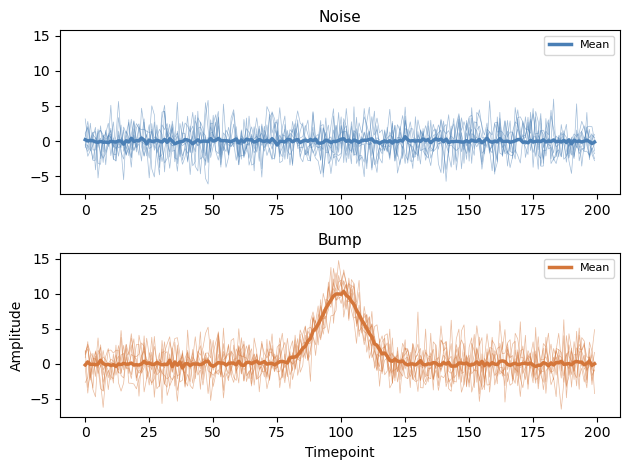

In [4]:
# Plot class-mean signals with individual trial examples
fig, axes = plt.subplots(2, 1, sharey=True)
class_names = ["Noise", "Bump"]
colors = ['#4A7FB5','#D4763A']
for k in range(2):
    ax = axes[k]
    mask = y == k
    # Plot a few individual trials
    for i in np.where(mask)[0][:8]:
        ax.plot(X[i], color=colors[k], alpha=0.5, linewidth=0.5)
    # Plot class mean
    ax.plot(X[mask].mean(axis=0), color=colors[k], linewidth=2.5, label="Mean")
    ax.set_title(class_names[k], fontsize=11)
    if k == 1:
        ax.set_ylabel("Amplitude")
        ax.set_xlabel("Timepoint")
    ax.legend(fontsize=8)
plt.tight_layout()

In [5]:
# for demonstration purposes, the model is fit on all data
model = IR.InterpRocket(
    max_dilations_per_kernel=16,
    num_features=10000,
    random_state=42,
)
model.fit(X, y)

InterpRocket.fit: 200 instances × 200 timepoints
  Classes: [0 1]
  Fitting dilations (raw)...
  Fitting biases (raw): 3108 biases across 5 dilations...
  Fitting dilations (diff)...
  Fitting biases (diff): 3108 biases across 5 dilations...
  Transforming training data...
  Feature matrix: (200, 24864)
  Standardizing features...
  Fitting RidgeClassifierCV...
  Training accuracy: 1.0000
  Selected alpha: 0.0000


,max_dilations_per_kernel,16
,num_features,10000
,random_state,42
,alpha_range,array([1.0000...00000000e+10])
,class_weight,None


In [6]:
# Feature stability analysis
stability = IR.cv_feature_stability(X, y, n_repeats=5, n_folds=5, n_top=50)
stable_features = IR.get_stable_features(stability, threshold=0.8)

CV feature stability: 5x5 folds, tracking top 50 features per fold
  Round 1/5: 113 features appeared in every round so far
  Round 2/5: 84 features appeared in every round so far
  Round 3/5: 83 features appeared in every round so far
  Round 4/5: 75 features appeared in every round so far
  Round 5/5: 74 features appeared in every round so far

  Features in ALL folds:  4
  Features in ≥80% folds: 17
  Features in NO folds:   11908
Stable features (≥80% of 25 folds): 17


In [7]:
top = model.get_top_features(feature_mask=stable_features)
for f in top:
    print(f"feature_index={f['feature_index']:>5d}  "
          f"kernel={f['kernel_index']:>2d}  d={f['dilation']:>3d}  "
          f"{f['pooling_op']:>4s}  {f['representation']:>4s}  "
          f"imp={f['importance']:.4f}")

feature_index= 4739  kernel= 1  d=  4  LSPV   raw  imp=1.0000
feature_index= 3735  kernel=49  d=  2  LSPV   raw  imp=0.9413
feature_index= 5975  kernel=39  d=  4  LSPV   raw  imp=0.8650
feature_index= 4719  kernel= 0  d=  4  LSPV   raw  imp=0.8093
feature_index= 5107  kernel=12  d=  4  LSPV   raw  imp=0.7967
feature_index= 4771  kernel= 2  d=  4  LSPV   raw  imp=0.7837
feature_index= 5683  kernel=30  d=  4  LSPV   raw  imp=0.5572
feature_index= 5443  kernel=23  d=  4  LSPV   raw  imp=0.5445
feature_index= 3727  kernel=49  d=  2  LSPV   raw  imp=0.3315
feature_index= 5538  kernel=26  d=  4  MIPV   raw  imp=0.2690
feature_index= 5851  kernel=35  d=  4  LSPV   raw  imp=0.2531
feature_index= 5987  kernel=40  d=  4  LSPV   raw  imp=0.1370
feature_index= 6039  kernel=41  d=  4  LSPV   raw  imp=0.1130
feature_index= 4030  kernel=59  d=  2  MIPV   raw  imp=0.0754
feature_index= 4287  kernel=69  d=  2  LSPV   raw  imp=0.0431
feature_index= 3619  kernel=45  d=  2  LSPV   raw  imp=0.0422
feature_

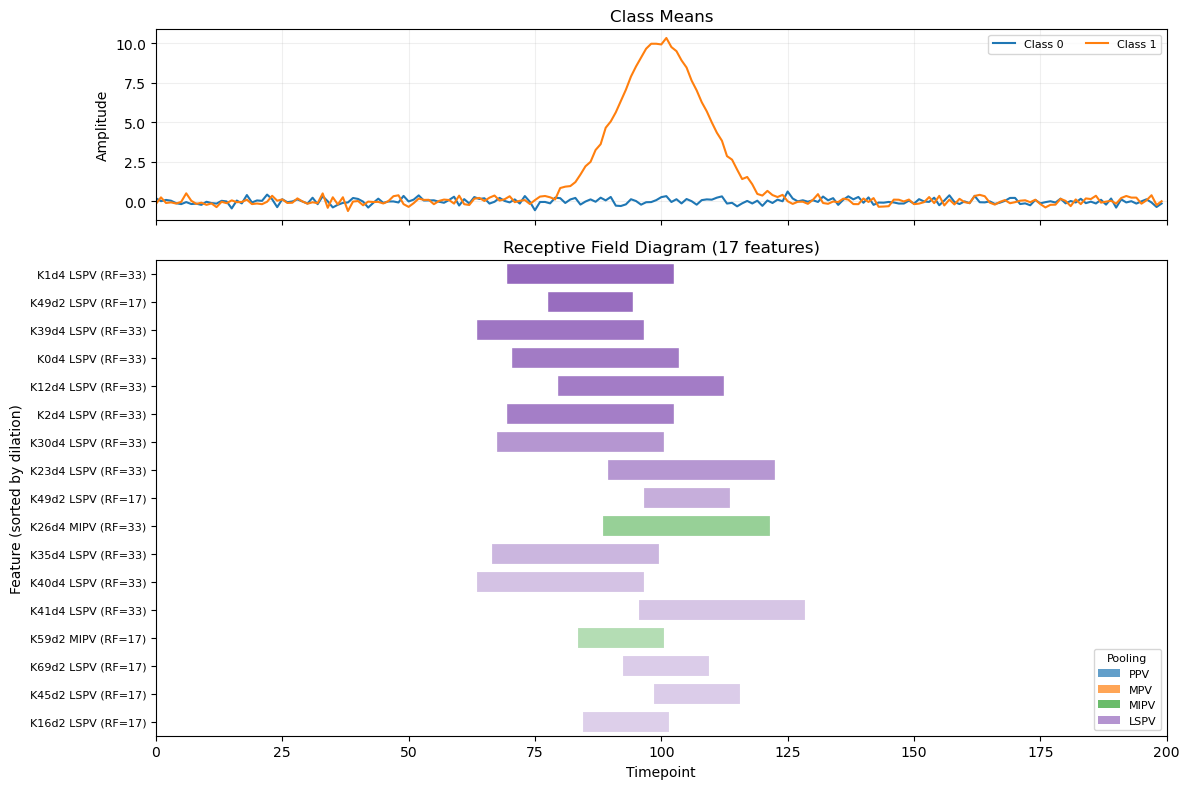

In [8]:
fig = IR.plot_receptive_field_diagram(model, X, y, feature_mask=stable_features)